CNN 학습 결과가 잘 나오는 MNIST 데이터셋으로 실습을 진행해봅시다!

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import cv2
import matplotlib.pyplot as plt

In [2]:
# myCNN 클래스 정의
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size = 5, padding = 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 5, padding = 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 5, padding = 2)
        self.fc1 = nn.Linear(128*3*3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.relu(F.max_pool2d(self.conv3(x), 2))
        x = x.view(-1, 128*3*3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim = 1)

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST('./data', train = False, transform = transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 1000, shuffle = False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.50MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.72MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



모델, 손실 함수, 최적화 알고리즘 설정 ✅

In [6]:
# TODO
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = myCNN().to(device)
criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
test_losses = []
test_accuracies = []


모델 학습 ✅

In [7]:
# TODO
def train(model, device, train_loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()               # 기울기 초기화
        output = model(data)                # 순전파
        loss = criterion(output, target)    # 손실 계산
        loss.backward()                     # 역전파
        optimizer.step()                    # 가중치 업데이트
        running_loss += loss.item() * data.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss

모델 평가 ✅

In [8]:
# TODO
def evaluate(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            test_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    epoch_loss = test_loss / len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    return epoch_loss, accuracy

10회 반복 ✅

In [9]:
# TODO
num_epochs = 10
for epoch in range(1, num_epochs+1):
    train_loss = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_accuracy = evaluate(model, device, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f'Epoch: {epoch}, Training Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

Epoch: 1, Training Loss: 0.1366, Test Loss: 0.0381, Test Accuracy: 98.73%
Epoch: 2, Training Loss: 0.0377, Test Loss: 0.0336, Test Accuracy: 98.90%
Epoch: 3, Training Loss: 0.0272, Test Loss: 0.0289, Test Accuracy: 99.13%
Epoch: 4, Training Loss: 0.0187, Test Loss: 0.0460, Test Accuracy: 98.65%
Epoch: 5, Training Loss: 0.0158, Test Loss: 0.0283, Test Accuracy: 99.15%
Epoch: 6, Training Loss: 0.0133, Test Loss: 0.0270, Test Accuracy: 99.37%
Epoch: 7, Training Loss: 0.0131, Test Loss: 0.0260, Test Accuracy: 99.30%
Epoch: 8, Training Loss: 0.0109, Test Loss: 0.0286, Test Accuracy: 99.33%
Epoch: 9, Training Loss: 0.0090, Test Loss: 0.0342, Test Accuracy: 99.20%
Epoch: 10, Training Loss: 0.0101, Test Loss: 0.0362, Test Accuracy: 99.13%


결과 시각화

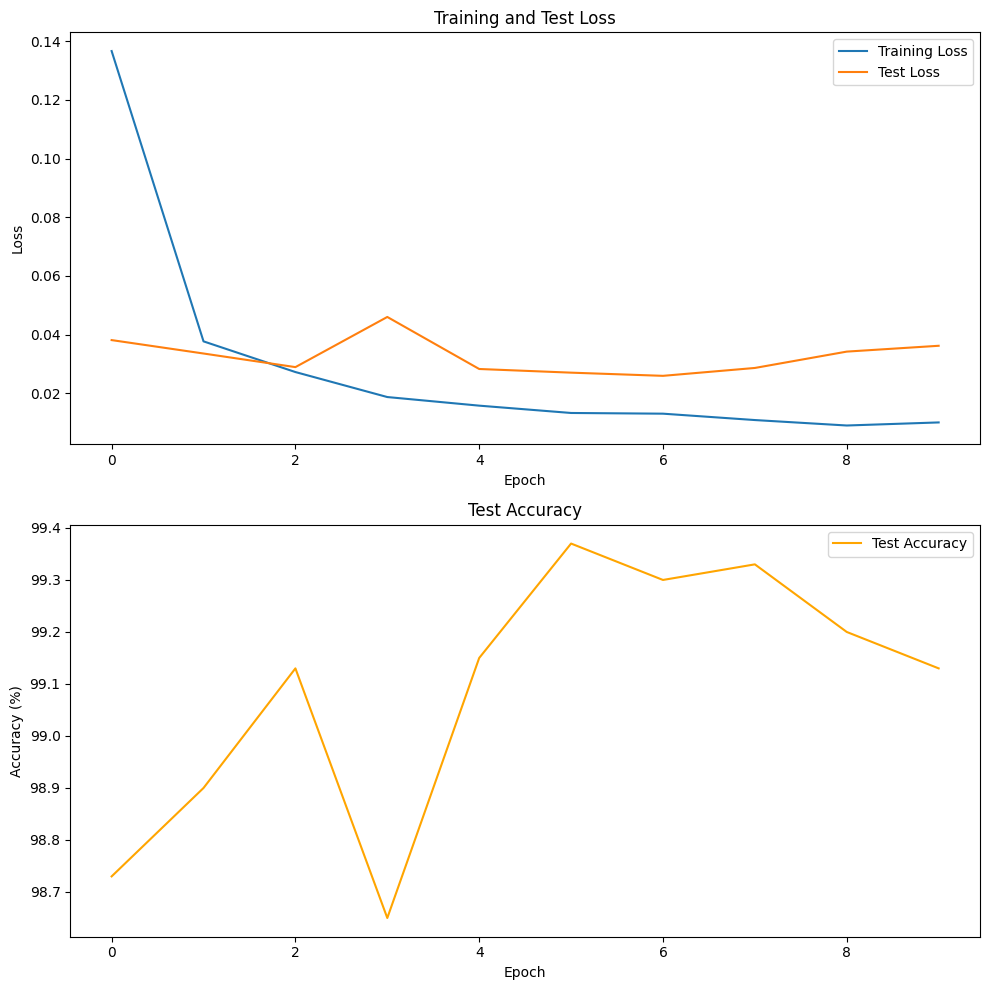

In [10]:
# 손실 및 정확도 시각화
fig, axs = plt.subplots(2,1,figsize=(10,10))
axs[0].plot(train_losses, label = 'Training Loss')
axs[0].plot(test_losses, label = 'Test Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].set_title('Training and Test Loss')

axs[1].plot(test_accuracies, label='Test Accuracy', color='orange')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].set_title('Test Accuracy')

plt.tight_layout()
plt.show()